In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
from util import calc_deltas, model_marker_mapper, method_color_mapper, model_name_mapper, method_name_mapper


In [2]:
delta_plotdir = "/u/rfechner/verl/plots/deltas"

# Enable LaTeX for all text
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
})

In [3]:
taxonomy_name_mapper = {
    'error_types' : "Error Types",
    'reasoning_types' : "Reasoning Types",
    'reasoning_strategies' : "Reasoning Strategies"
}

In [4]:
deltas = calc_deltas(recompute=True)
passk_keys = [k for k in deltas.keys()]
for k in passk_keys:
    if k.endswith('gspo') or k.startswith('qwen2.5_1.5b'):
        del deltas[k]

Methods: 100%|██████████| 16/16 [01:03<00:00,  3.99s/it]


Serializing to /ptmp/rfechner/out/exp13_deltas/cache.pickle


In [5]:
from copy import deepcopy
def binnings(deltas : dict, anchor_percentile : int = 50, delta_percentile : int = 50) -> dict:
    """
        We're binning the deltas based on their likelihoods. We're binning
        per-checkpoint to counteract preference shift during training.

        output are samples of the intersection of
        - the high-bins for anchors per behaviour (high likelihood ground truth responses) 
        - the low-bins for distance between anchor and augmentation. (reasonable likelihoods of augmentation being sampled)

        This aims at removing noise in the augmentations and counteract preference shift.
    """

    # iterate over deltas, build clone
    clone = deepcopy(deltas)
    for method, checkpoints in deltas.items():
        for checkpoint, taxonomies in checkpoints.items():
            for taxonomy_name, taxonomy in taxonomies.items():
                for behaviour, values in taxonomy.items():
                    if behaviour == 'anchor':
                        continue
                
                    if taxonomy_name=='error_types': # for error types, anchors are split across behaviours.
                        anchor_dictionary = taxonomy['anchor'].item()
                        anchor = np.array(anchor_dictionary[behaviour])
                    else:
                        anchor = taxonomy['anchor']

                    top_percentile = np.percentile(anchor, anchor_percentile)
                    high_indices = (anchor >= top_percentile).squeeze()
                    bottom_percentile = np.percentile(values, delta_percentile)
                    low_indices = values <= bottom_percentile
                    intersection = high_indices & low_indices
                    clone[method][checkpoint][taxonomy_name][behaviour] = values[intersection]

                del clone[method][checkpoint][taxonomy_name]['anchor']
    return clone

def binnings_old(
    deltas: dict,
    anchor_min_lp: float = -3.0,
    delta_bins: tuple[float, float] = (0.0, 1.0),
) -> dict:
    """
    Selection logic (per checkpoint):
    - Anchor must have sufficiently high absolute likelihood
      (anchor >= anchor_min_lp)
    - Delta magnitude must fall within a fixed absolute bin:
        delta_bins[0] <= |Δlogp| < delta_bins[1]
    """

    clone = deepcopy(deltas)
    per_checkpoint_drops = {m : {} for m in deltas.keys()}
    for method, checkpoints in deltas.items():
        for checkpoint, taxonomies in checkpoints.items():
            per_checkpoint_drops[method][checkpoint] = []
            for taxonomy_name, taxonomy in taxonomies.items():
                for behaviour, values in taxonomy.items():
                    if behaviour == "anchor":
                        continue

                    # Resolve anchor values
                    if taxonomy_name == "error_types":
                        anchor_dict = taxonomy["anchor"].item()
                        anchor = np.array(anchor_dict[behaviour])
                    else:
                        anchor = np.asarray(taxonomy["anchor"])

                    # Binning in absolute terms
                    values = np.asarray(values)
                    anchor_mask = (anchor >= anchor_min_lp).squeeze()
                    delta_abs = np.abs(values)
                    delta_mask = (
                        (delta_abs >= delta_bins[0]) &
                        (delta_abs < delta_bins[1])
                    ).squeeze()
                    intersection = anchor_mask & delta_mask
                    per_checkpoint_drops[method][checkpoint].append(sum(~intersection))
                    clone[method][checkpoint][taxonomy_name][behaviour] = values[intersection]

                # Remove anchor after processing
                del clone[method][checkpoint][taxonomy_name]["anchor"]
    for m, cps in per_checkpoint_drops.items():
        drops = [sum(vs) for vs in cps.values()]
        # print(f"Method: {m} dropped: [{drops}]")
    return clone

In [6]:
from collections import defaultdict

def preprocess(
    data: dict,
    methods: list[str] | None = None,
    models: list[str] | None = None,
    taxs: list[str] | None = None,
):
    """
    Reshape data for plotting.

    Output structure:
        taxonomy -> category -> method -> list[per-checkpoint means]
    """

    # taxonomy -> category -> method -> [values]
    result = defaultdict(
        lambda: defaultdict(lambda: defaultdict(list))
    )

    for key, checkpoints in data.items():
        model, method = key.split('__')

        if methods and method not in methods:
            continue
        if models and model not in models:
            continue

        for cp, taxonomies in checkpoints.items():
            for tax_name, categories in taxonomies.items():
                if taxs and tax_name not in taxs:
                    continue

                # compute per-checkpoint mean per category
                for category, values in categories.items():
                    result[tax_name][category][key].append(
                        np.mean(values)
                    )

    return result

In [7]:
models, methods = zip(*[x.split('__') for x in deltas.keys()])
models, methods = set(models), set(methods)

In [8]:
import matplotlib.pyplot as plt
from math import ceil
def plot_helper(data, taxonomy : str):
    categories = list(data.keys())
    nrows, ncols = 2, ceil(len(categories) / 2)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(2.2*ncols, 2.2*nrows), sharex=True)
    axes = axes.flatten()
    for i, ax, (category, model_method_dict) in zip(range(len(axes)), axes, data.items()):

        # plot for current category
        for model_method, values in model_method_dict.items():
            model, method = model_method.split('__')
            color, marker = method_color_mapper[method], model_marker_mapper[model]
            xs = np.arange(len(values)) * 10
            ax.plot(xs, values, marker=marker, color=color, label=f'{method_name_mapper[method]}')
        ax.set_title(category)
        ax.grid(True)
        if i % ncols == 0:
            ax.set_ylabel(r"$\Delta := \log p(\tilde x | \theta_i) - \log p(x| \theta_i)$")
        if i >= ncols:
            ax.set_xlabel(r"$\theta_i$")
    for empty_ax in axes[len(categories):]:
        empty_ax.axis('off')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center",
        ncol=4,
        frameon=True,
        bbox_to_anchor=(0.5, -0.05))
    plt.tight_layout()
    plt.suptitle(f"Behavior: {taxonomy_name_mapper[taxonomy]}, Model: {model_name_mapper[model]}", y=1.05, fontsize=15)
    outfile = f"behaviors_tax_{taxonomy_name_mapper[taxonomy]}__model_{model_name_mapper[model]}.pdf"
    fig.savefig(os.path.join(delta_plotdir, outfile), format="pdf", bbox_inches="tight")
    plt.show()

In [9]:
binned = binnings_old(deltas)

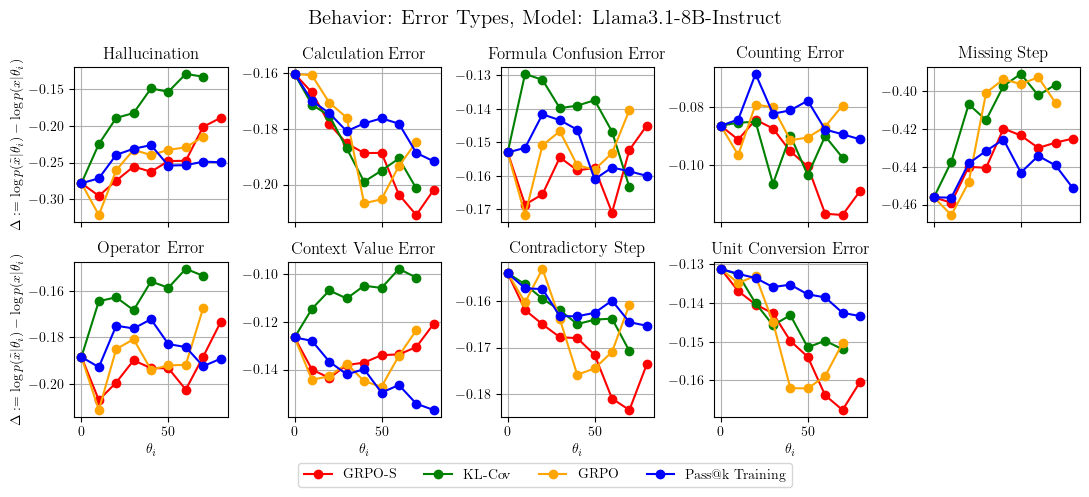

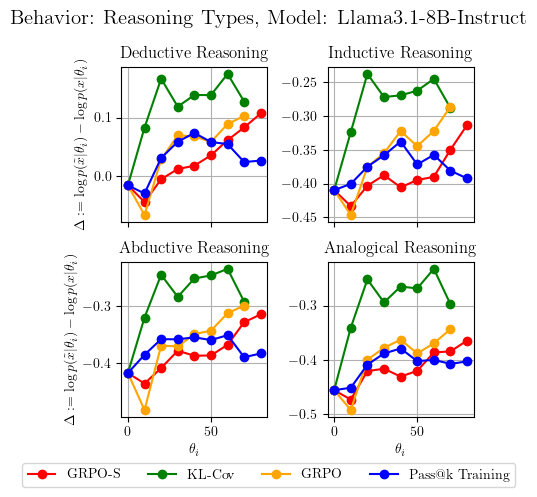

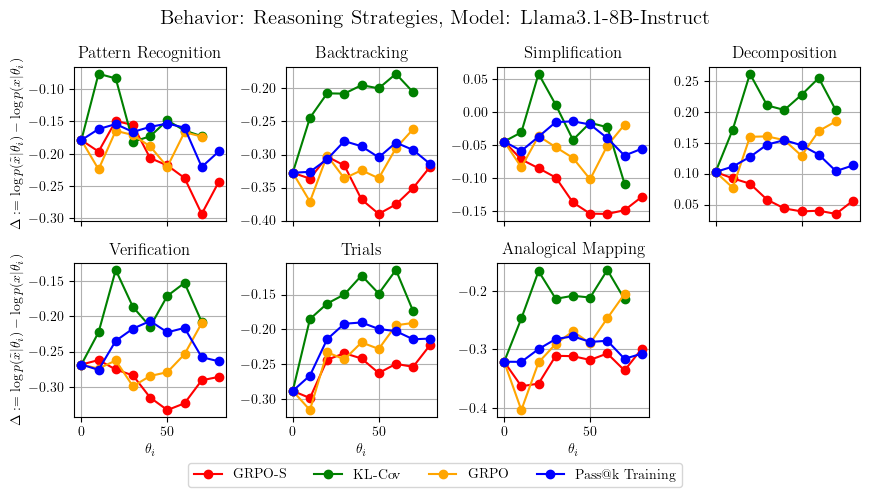

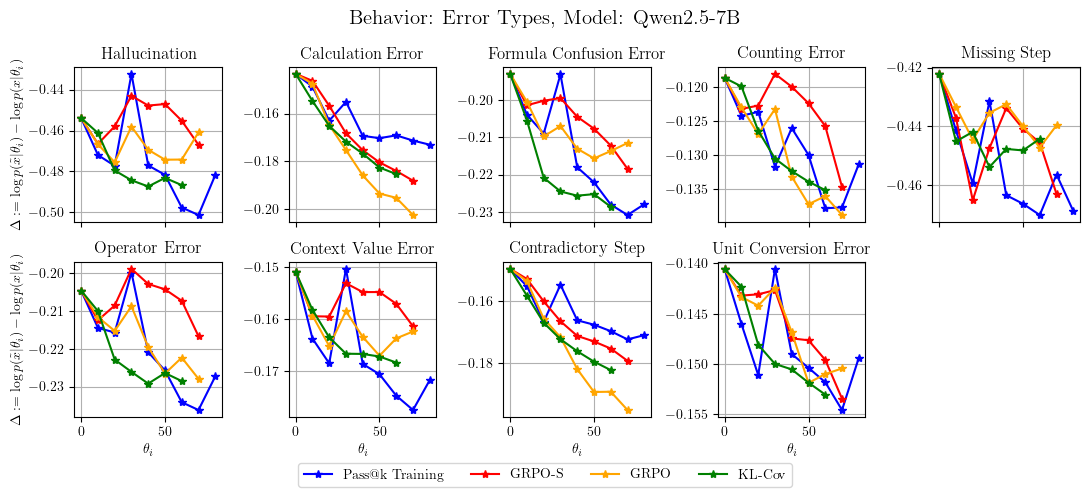

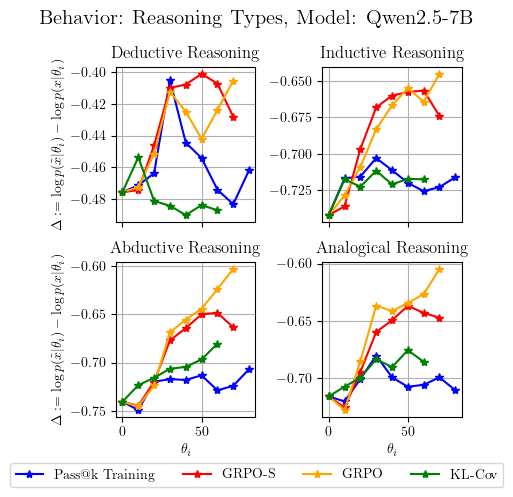

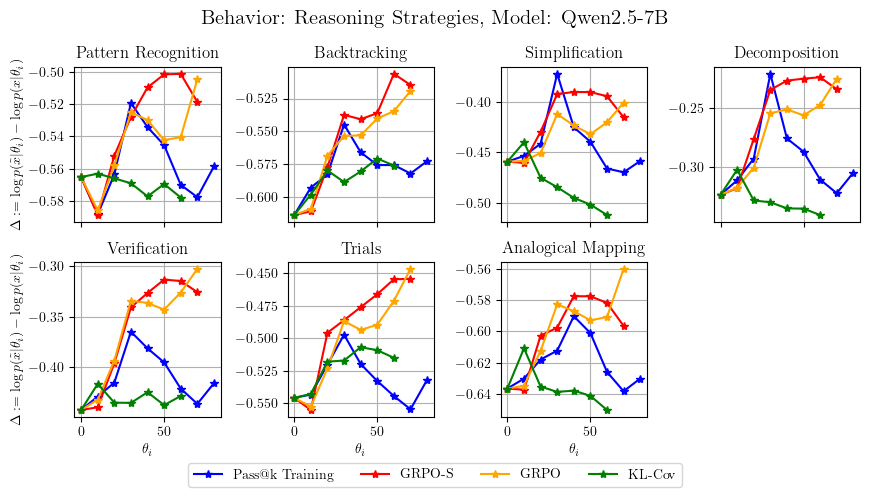

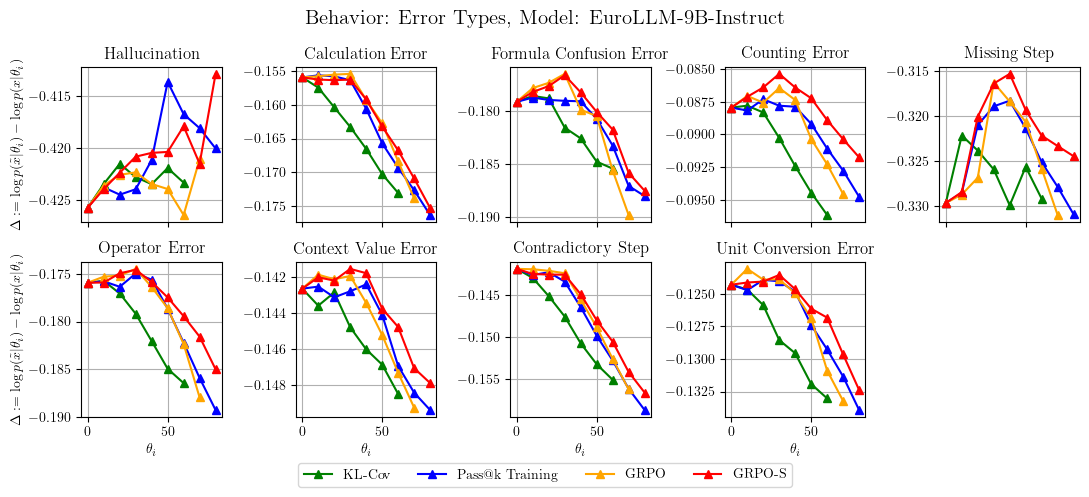

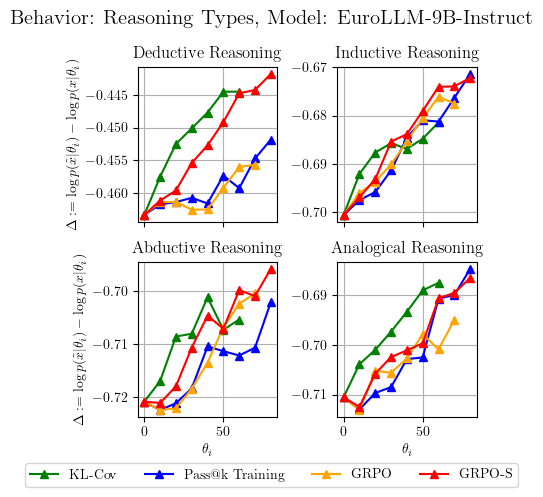

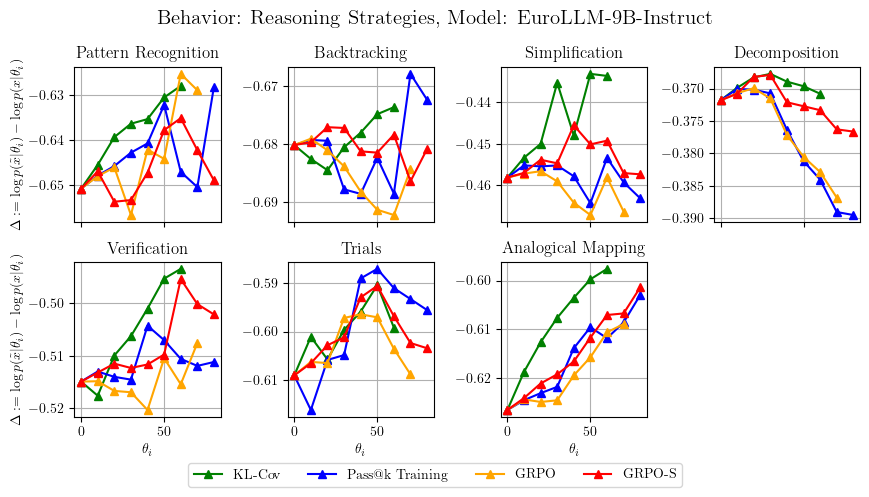

In [10]:

for model in models:
    processed = preprocess(binned, models=[model])
    for taxonomy, data in processed.items():
        plot_helper(data, taxonomy=taxonomy)

In [11]:
# repeating the correlation plots from the prelim experiments
from util import rollouts

In [12]:
# preprocess rollouts for correlation analysis
# we'll collect [method pass@1] values
vs = rollouts(recompute=False)

Reading Experiment 13 + selective Qwen2.5-7B rollouts.


In [13]:
def preprocess_rollouts(vs : dict) -> dict:
    ret = defaultdict()

    for method, checkpoints in vs.items():
        pass1 : list[float|np.float32] = []
        debug_cp = 0
        for cp, datasets in checkpoints.items():
            curcp = int(cp)
            if debug_cp > curcp:
                raise ValueError("Checkpoint sorting off.")
            debug_cp = curcp
            pass1_cp : list[np.ndarray]= []
            for ds in datasets.values():
                pass1_cp.append(ds[:, 0]) # take pass@1 estimate.
            pass1.append(np.mean(np.concat(pass1_cp)))
        ret[method] = pass1
    return ret

In [14]:
pass1_values = preprocess_rollouts(vs)

In [15]:
def correlations(
    processed: dict,
    pass1_permethod: dict,
):
    """
    For each taxonomy, plot a heatmap:
        x-axis: behaviour
        y-axis: method
        color: correlation(delta, pass@1)

    All taxonomies are shown as subplots in a single row.
    """
    from collections import defaultdict
    import numpy as np
    import matplotlib.pyplot as plt

    mapper = {}
    taxonomies = list(processed.keys())

    # infer methods from first taxonomy / behaviour
    first_tax = taxonomies[0]
    first_behaviour = next(iter(processed[first_tax]))
    methods = sorted(set(processed[first_tax][first_behaviour].keys()))

    
    # ---- compute correlation matrices ----
    for taxonomy, behaviours in processed.items():
        behaviour_names = sorted(behaviours.keys())

        # NOTE: rows = methods, cols = behaviours (already transposed)
        corr_matrix = np.full(
            (len(methods), len(behaviour_names)),
            np.nan
        )

        for j, behaviour in enumerate(behaviour_names):
            for i, method in enumerate(methods):
                if method not in behaviours[behaviour]:
                    raise ValueError(f"{method} missing for {behaviour} in {taxonomy}")

                deltas = np.asarray(behaviours[behaviour][method])
                pass1 = np.asarray(pass1_permethod[method])

                if len(deltas) != len(pass1):
                    print(f"Method: {method}")
                    print(len(deltas), len(pass1))
                    raise ValueError(f"Length mismatch for {method}")

                corr_matrix[i, j] = np.corrcoef(deltas, pass1)[0, 1]

        mapper[taxonomy] = (corr_matrix, behaviour_names)

    # ---- plotting ----
    n_tax = len(taxonomies)
    fig, axes = plt.subplots(
        1,
        n_tax,
        figsize=(3.0 * sum(len(mapper[t][1]) for t in taxonomies) / n_tax,
                 0.6 * len(methods)),
        squeeze=False,
        sharey=True,
    )

    for i, (ax, taxonomy) in enumerate(zip(axes[0], taxonomies)):
        corr_matrix, behaviour_names = mapper[taxonomy]

        im = ax.imshow(corr_matrix, vmin=-1, vmax=1, aspect="auto")

        ax.set_xticks(range(len(behaviour_names)))
        ax.set_xticklabels(behaviour_names, rotation=45, ha="right")

        mo, me = zip(*[x.split('__') for x in methods])
        ax.set_yticks(range(len(methods)))
        ax.set_yticklabels(map(lambda model, method: f"{model_name_mapper[model]}, {method_name_mapper[method]}", mo, me))
        ax.set_title(taxonomy_name_mapper[taxonomy])

    mo, me = zip(*[m.split('__') for m in methods])
    mo, me = sorted(set(mo)), sorted(set(me))

    axes[0][0].set_ylabel("Model, Method")
    
    fig.colorbar(im, ax=axes.ravel().tolist(), label="Pearson correlation")
    fig.suptitle(fr"$\Delta$ logprob $\leftrightarrow$ pass@1 correlation", y=1.2, fontsize=16)
    outfile = f"behaviors_correlations__Models:{'--'.join(mo)}__Methods:{'--'.join(me)}.pdf"
    fig.savefig(os.path.join(delta_plotdir, outfile), format="pdf", bbox_inches="tight")
    plt.show()

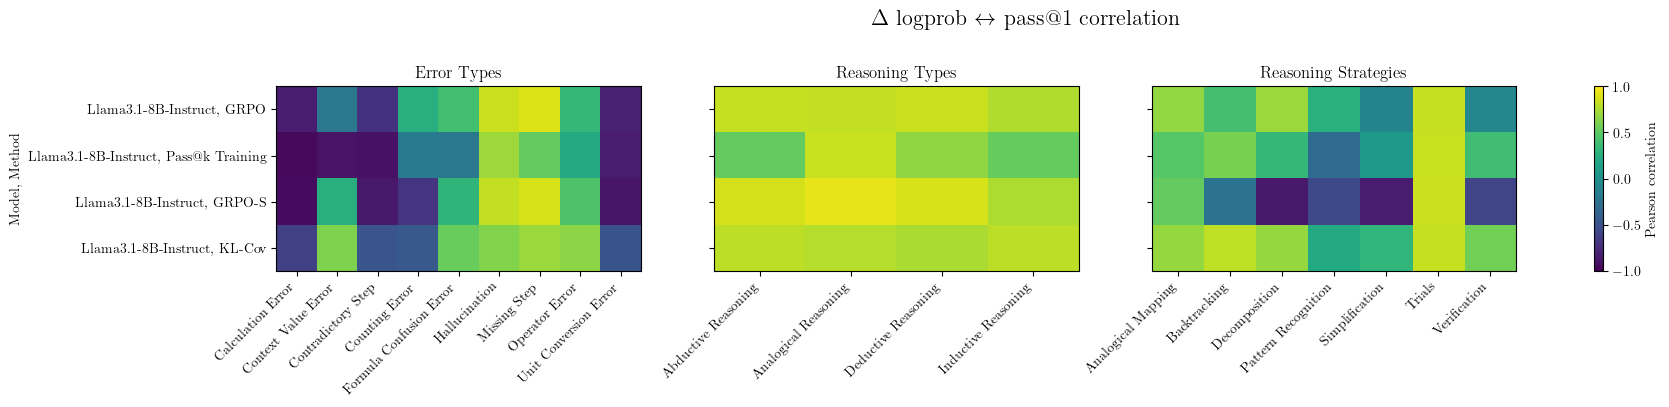

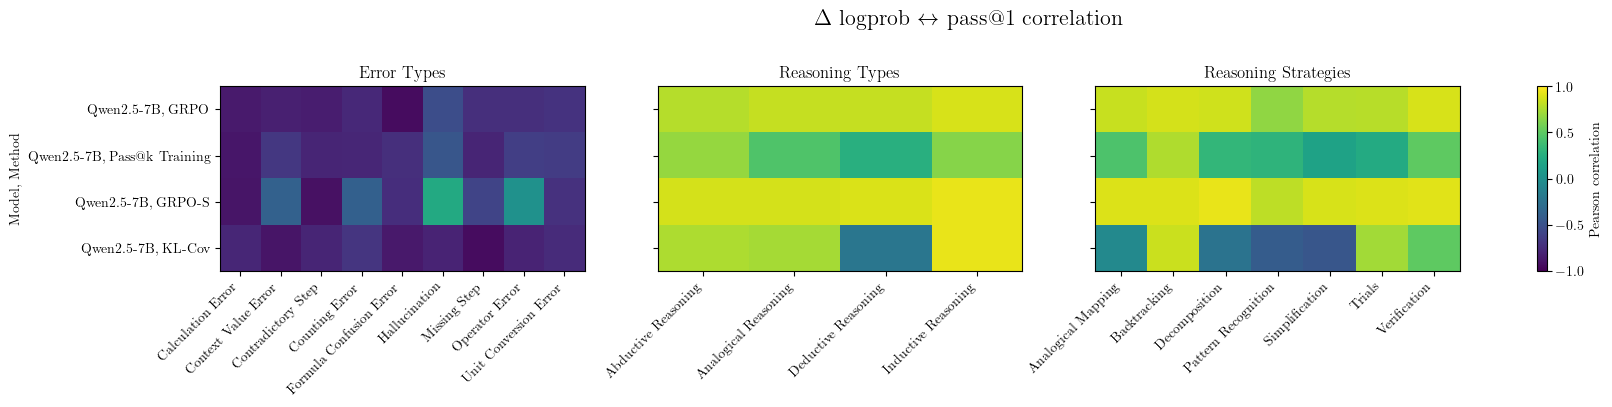

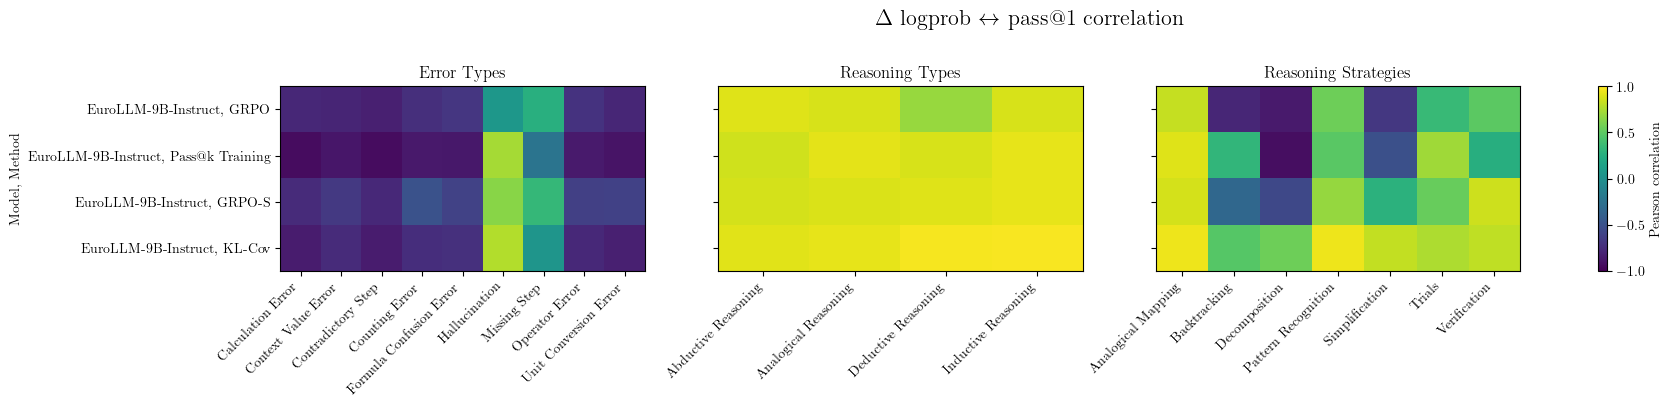

In [16]:
for model in models:
    binned = binnings_old(deltas)
    processed = preprocess(binned, models=[model])
    correlations(processed=processed, pass1_permethod=pass1_values)

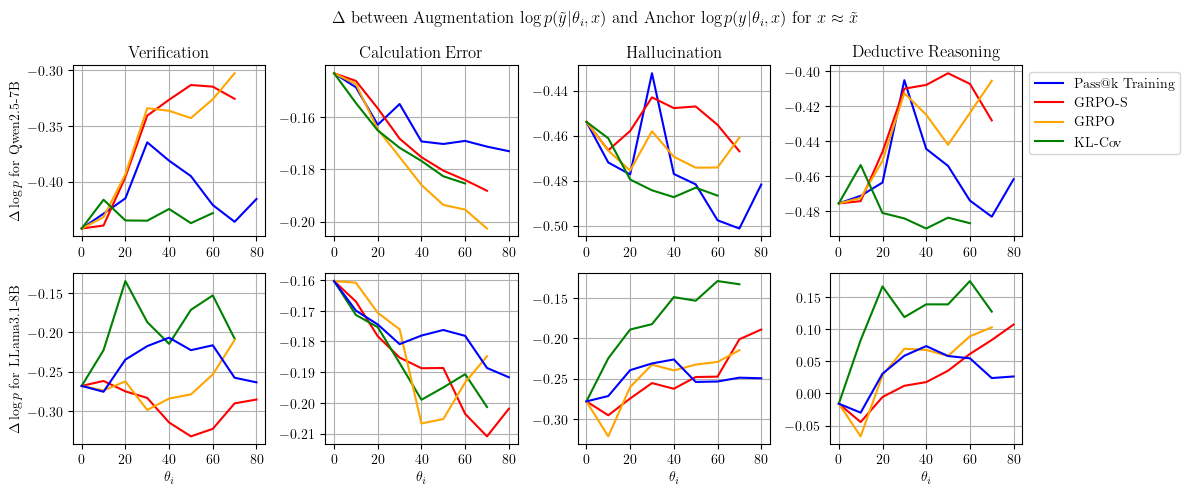

In [17]:
# plotting Results section delta plot.
# we'd like a 2 by 4 plot 


def deltas_subsection(all_data):
    """
        all_data[taxonomy][class][method] = values
    """
    taxonomy_class_tuples = [('reasoning_strategies', 'Verification'),
                             ('error_types', 'Calculation Error'),
                             ('error_types', 'Hallucination'),
                             ('reasoning_types', 'Deductive Reasoning')]
    models = ['qwen2.5_7b', 'llama_3.1_8b_instruct']
    
    fig, axes = plt.subplots(nrows=2, ncols=len(taxonomy_class_tuples), figsize=(len(taxonomy_class_tuples) * 3, 5))
    qwen_axes, llama_axes = axes[0, :], axes[1, :]
    xs, xticks = np.arange(9), 10 * np.arange(9)

    for ax, (tax, cls) in zip(qwen_axes, taxonomy_class_tuples):
        for model_method_key, vs in all_data[tax][cls].items():
            model, method = model_method_key.split('__')
            if models[0] not in model_method_key:
                continue
            ax.plot(vs, label=method_name_mapper[method], color=method_color_mapper[method])
            ax.set_title(cls)
            ax.set_xticks(xs[::2], xticks[::2])
            ax.grid(True)
    
    for ax, (tax, cls) in zip(llama_axes, taxonomy_class_tuples):
        for model_method_key, vs in all_data[tax][cls].items():
            model, method = model_method_key.split('__')
            if models[1] not in model_method_key:
                continue
            ax.plot(vs, label=method_name_mapper[method], color=method_color_mapper[method])
            ax.set_xlabel(r"$\theta_i$")
            ax.set_xticks(xs[::2], xticks[::2])
            ax.grid(True)

    qwen_axes[0].set_ylabel(r"$\Delta \log p$ for Qwen2.5-7B")
    llama_axes[0].set_ylabel(r"$\Delta\log p$ for LLama3.1-8B")
    qwen_axes[-1].legend(bbox_to_anchor=(1, 1))

    plt.suptitle(r"$\Delta$ between Augmentation $\log p(\tilde y|\theta_i, x)$ and Anchor $\log p(y|\theta_i, x)$ for $x \approx \tilde x$")
    plt.tight_layout()
    outfile = f"behaviors_overview.pdf"
    fig.savefig(os.path.join(delta_plotdir, outfile), format="pdf", bbox_inches="tight")
    plt.show()
processed = preprocess(binned, models=['qwen2.5_7b', 'llama_3.1_8b_instruct'])
deltas_subsection(processed)   